## Análisis de rendimiento: definición de "temporada buena vs mala"

Este notebook parte de `df_maestro.csv`, ya construido y validado en `01_exploracion_estructura.ipynb`. Aquí se define una métrica compuesta de rendimiento por temporada y se realiza el análisis exploratorio de la relación entre gasto, entrenador y rendimiento.

### Decisión de diseño: qué define una "temporada buena"

El fútbol es un deporte resultadista: el objetivo de cada temporada no es alcanzar una cifra específica de puntos, es terminar por delante del resto de la liga. Por eso, la categoría de éxito/fracaso de una temporada (`categoria_temporada`) se define exclusivamente por **posición final**, no por puntos.

Además, la escala se ajusta al contexto específico del Barça, no a un estándar genérico de club de mitad de tabla: para un club de esta escala, no clasificar a Champions League ya representa una temporada fallida, no hay una zona "aceptable" intermedia entre pelear el título y quedar fuera de Europa.

- **Título**: posición 1
- **Top 4**: posición 2 a 4 (zona de clasificación directa a Champions League)
- **Mala**: posición 5 a 8 (fuera de Champions, pero probablemente todavía dentro de zona de competición europea menor, Europa League o Conference League)
- **Catastrófico**: posición 9 en adelante (fuera de toda competición europea, sin nada que pelear el resto de la temporada)

En paralelo, se calcula `rendimiento_relativo`, una variable continua (puntos obtenidos sobre el máximo de puntos posible esa temporada específica). Esta normalización es necesaria porque los puntos crudos no son comparables entre eras: la regla de puntos por victoria cambió de 2 a 3 en 1995/96, y dos temporadas (1995/96 y 1996/97) tuvieron 42 partidos en vez de 38. `rendimiento_relativo` corrige ambas diferencias sin modificar el dato base de puntos, que se mantiene fiel a la clasificación real de cada año.

**Uso previsto de cada variable:** `categoria_temporada` se usa para comparaciones narrativas y visualizaciones (por ejemplo, cuántas temporadas de título tuvo cada entrenador). `rendimiento_relativo` se usa para análisis estadístico que requiere una variable numérica continua, como la correlación entre gasto neto y rendimiento. No se usa gasto ni entrenador como parte de la definición de "temporada buena", para evitar que el criterio de éxito quede contaminado por las mismas variables que después se van a analizar en relación a él.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr

df_maestro = pd.read_csv('../data/processed/df_maestro.csv', dtype={'temporada': str})
df_maestro.head()

,temporada,posicion,puntos,partidos_jugados,victorias,empates,derrotas,goles_favor,goles_contra,diferencia_gol,anio_inicio,entrenador_principal,hubo_cambio_entrenador,gasto_compras,ingreso_ventas,gasto_neto,fuente_gasto,gasto_total_liga,proporcion_mercado_barca
0,9394,1,56,38,25,6,7,91,42,49,1993,Johan Cruyff,False,8650000.0,0.0,8650000.0,manual,46826024.0,0.184726
1,9495,4,46,38,18,10,10,60,45,15,1994,Johan Cruyff,False,12050000.0,14850000.0,-2800000.0,manual,58083061.0,-0.048207
2,9596,3,80,42,22,14,6,72,39,33,1995,Johan Cruyff,True,16800000.0,17000000.0,-200000.0,manual,81630870.0,-0.002450
3,9697,2,90,42,28,6,8,102,48,54,1996,Bobby Robson,False,42800000.0,10920000.0,31880000.0,manual,252865057.0,0.126075
4,9798,1,74,38,23,5,10,78,56,22,1997,Louis van Gaal,False,67450000.0,40800000.0,26650000.0,manual,354451775.0,0.075187


In [29]:
df_maestro['puntos_por_victoria'] = df_maestro['temporada'].apply(lambda t: 2 if t in ['9394', '9495'] else 3)
df_maestro['puntos_maximos_posibles'] = df_maestro['partidos_jugados'] * df_maestro['puntos_por_victoria']
df_maestro['rendimiento_relativo'] = df_maestro['puntos'] / df_maestro['puntos_maximos_posibles']

df_maestro[['temporada', 'posicion', 'puntos', 'puntos_maximos_posibles', 'rendimiento_relativo']].head(10)

,temporada,posicion,puntos,puntos_maximos_posibles,rendimiento_relativo
0,9394,1,56,76,0.736842
1,9495,4,46,76,0.605263
2,9596,3,80,126,0.634921
3,9697,2,90,126,0.714286
4,9798,1,74,114,0.649123
5,9899,1,79,114,0.692982
6,9900,2,64,114,0.561404
7,0001,4,63,114,0.552632
8,0102,4,64,114,0.561404
9,0203,6,56,114,0.491228


In [30]:
def categorizar_temporada(posicion):
    if posicion == 1:
        return 'Título'
    elif posicion <= 4:
        return 'Top 4'
    elif posicion <= 8:
        return 'Mala'
    else:
        return 'Catastrófico'

df_maestro['categoria_temporada'] = df_maestro['posicion'].apply(categorizar_temporada)
df_maestro['categoria_temporada'].value_counts()

categoria_temporada
Título    16
Top 4     16
Mala       1
Name: count, dtype: int64

### Primera visualización: rendimiento relativo por temporada

El gráfico muestra tres patrones claros sin necesidad de ningún cruce adicional:

- **Valle más profundo: 2001/02**, coincidiendo con la etapa de Carles Rexach como entrenador principal, tras el cambio de Serra Ferrer a mitad de la temporada anterior. La etapa más floja del rango completo.
- **Meseta más alta: 2008-2013**, la era Guardiola-Vilanova, con el pico máximo absoluto en 2012/13 (temporada del récord de 100 puntos).
- **Caída marcada 2019-2021**, coincidiendo con la etapa de Koeman y la crisis institucional del club en ese periodo, con recuperación sostenida desde 2021/22 en adelante bajo Xavi y Flick.

Este patrón, visible antes de cruzar con gasto neto o formalizar el análisis por entrenador, sirve como primera validación de que `rendimiento_relativo` captura variación real del club a lo largo del tiempo, no ruido estadístico.

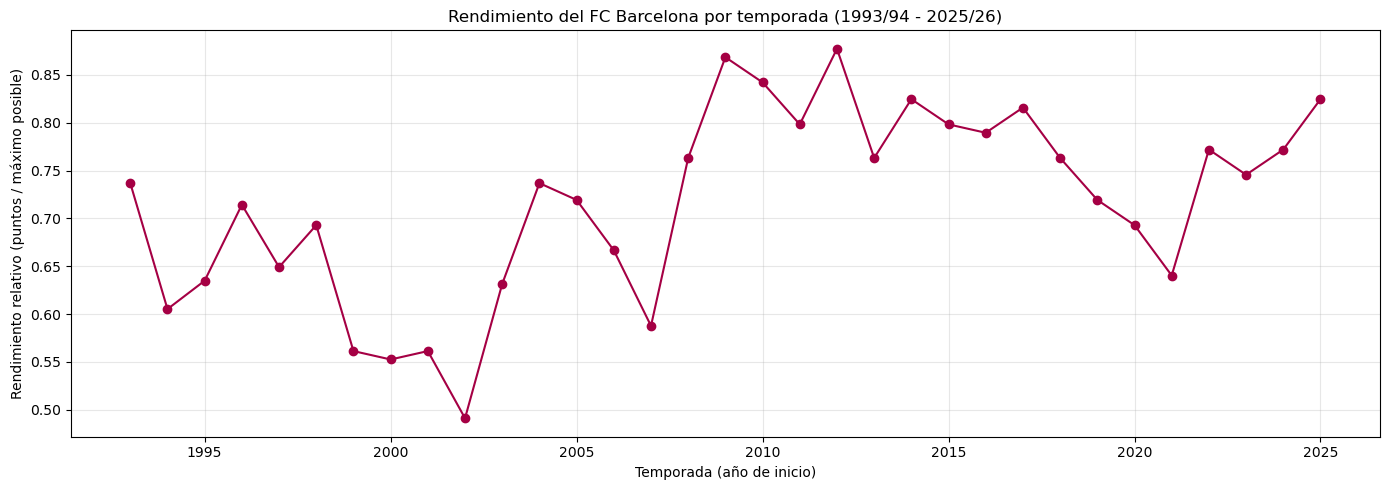

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_maestro['anio_inicio'], df_maestro['rendimiento_relativo'], marker='o', color='#a50044')
ax.set_xlabel('Temporada (año de inicio)')
ax.set_ylabel('Rendimiento relativo (puntos / máximo posible)')
ax.set_title('Rendimiento del FC Barcelona por temporada (1993/94 - 2025/26)')
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig('../reports/figures/rendimiento_por_temporada.png', dpi=150, bbox_inches='tight')
plt.show()

### Segunda visualización: proporción de mercado vs rendimiento (1993/94-2025/26)

A diferencia del primer intento (gasto absoluto, solo 12 temporadas), esta versión usa `proporcion_mercado_barca` (gasto neto del Barça como % del gasto total de La Liga esa temporada), lo que permite comparar las 33 temporadas del rango completo sin la distorsión de la inflación del mercado de fichajes entre épocas tan distintas.

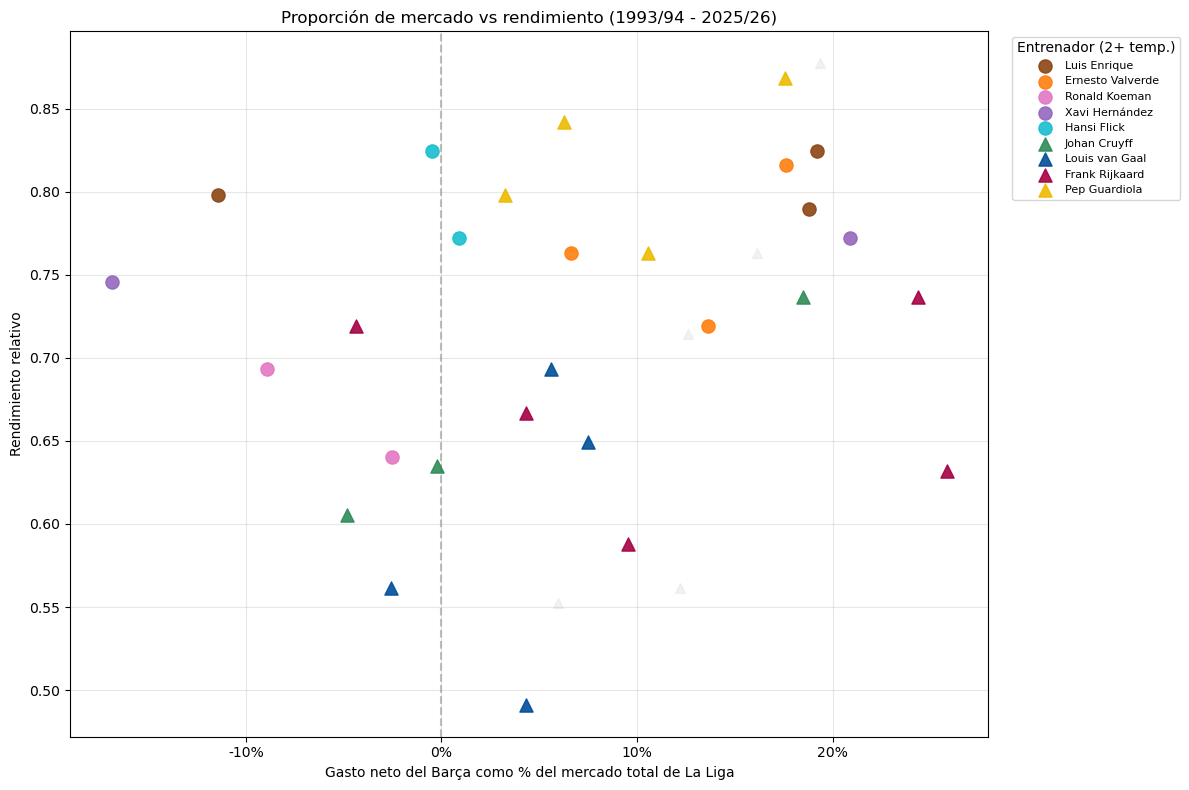

In [32]:
fig, ax = plt.subplots(figsize=(12, 8))

entrenadores_grandes = df_maestro['entrenador_principal'].value_counts()
entrenadores_grandes = entrenadores_grandes[entrenadores_grandes >= 2].index.tolist()

paleta = ['#a50044', '#004d98', '#edbb00', '#2e8b57', '#8B4513', '#ff7f0e', '#9467bd', '#17becf', '#e377c2']
mapa_color = dict(zip(entrenadores_grandes, paleta[:len(entrenadores_grandes)]))

etiquetados = set()

for fuente, marcador in [('automatizado', 'o'), ('manual', '^')]:
    subset = df_maestro[df_maestro['fuente_gasto'] == fuente]
    for entrenador in subset['entrenador_principal'].unique():
        sub = subset[subset['entrenador_principal'] == entrenador]
        es_grande = entrenador in entrenadores_grandes
        color = mapa_color.get(entrenador, '#e0e0e0')
        if es_grande and entrenador not in etiquetados:
            etiqueta = entrenador
            etiquetados.add(entrenador)
        else:
            etiqueta = None
        ax.scatter(sub['proporcion_mercado_barca'], sub['rendimiento_relativo'],
                   color=color, marker=marcador, s=90 if es_grande else 50,
                   alpha=0.9 if es_grande else 0.4, label=etiqueta,
                   zorder=3 if es_grande else 1)

ax.set_xlabel('Gasto neto del Barça como % del mercado total de La Liga')
ax.set_ylabel('Rendimiento relativo')
ax.set_title('Proporción de mercado vs rendimiento (1993/94 - 2025/26)')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Entrenador (2+ temp.)')
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig('../reports/figures/proporcion_mercado_vs_rendimiento.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_126011/2981432016.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_boxplot, labels=['Título', 'Top 4', 'Mala'], patch_artist=True)


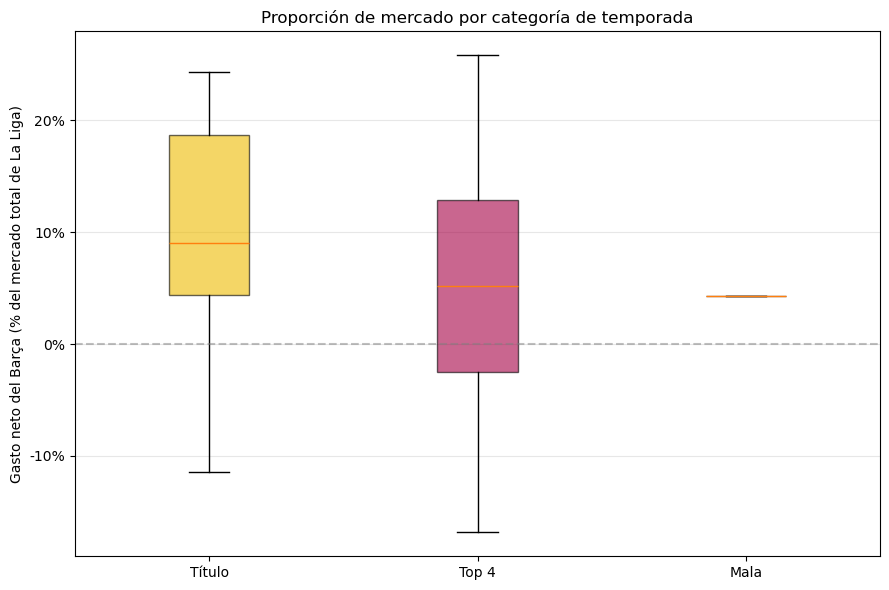

In [33]:
fig, ax = plt.subplots(figsize=(9, 6))

datos_boxplot = [df_maestro[df_maestro['categoria_temporada'] == cat]['proporcion_mercado_barca'].dropna()
                  for cat in ['Título', 'Top 4', 'Mala']]

bp = ax.boxplot(datos_boxplot, labels=['Título', 'Top 4', 'Mala'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#edbb00', '#a50044', '#888888']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.set_ylabel('Gasto neto del Barça (% del mercado total de La Liga)')
ax.set_title('Proporción de mercado por categoría de temporada')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig('../reports/figures/gasto_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()

### Proporción de mercado por categoría de temporada

Las temporadas de **Título muestran una mediana de gasto relativo más alta (~9%) que las de Top 4 (~5%)**, y su caja está desplazada hacia valores positivos (rango intercuartílico de 4.5% a 18.5%, contra -2.5% a 13% en Top 4). Esto sugiere una asociación moderada entre gastar más que el promedio del mercado y ganar la liga, aunque **el solapamiento entre ambas cajas es amplio**: hay temporadas de Título con gasto negativo (venta neta) y temporadas de Top 4 con gasto por encima del 20%, coherente con la correlación débil y no significativa ya calculada (r=0.227).

**"Mala" tiene una sola temporada** (2002/03, bajo Van Gaal/Antić), por eso aparece como una línea plana en ~4.3% en vez de una caja, no hay variación que mostrar con un solo dato. No se incluyó "Catastrófico" en el gráfico por no tener ninguna temporada en esa categoría.

**Lectura combinada con el resto del análisis:** el gasto relativo al mercado parece pesar algo más al distinguir entre "ganar el título" y "quedar fuera de él" que al predecir el rendimiento continuo exacto, pero la superposición entre categorías confirma que el entrenador y otros factores no capturados en este dataset siguen explicando una porción mayor del resultado que el dinero invertido por sí solo.

In [34]:
correlacion, p_valor = pearsonr(df_maestro['proporcion_mercado_barca'], df_maestro['rendimiento_relativo'])

print(f'Coeficiente de correlación (Pearson): {correlacion:.3f}')
print(f'Valor p: {p_valor:.3f}')

Coeficiente de correlación (Pearson): 0.227
Valor p: 0.204


### Correlación entre proporción de mercado y rendimiento (33 temporadas)

Se calculó el coeficiente de correlación de Pearson entre `proporcion_mercado_barca` y `rendimiento_relativo`, sobre las 33 temporadas completas del rango (1993/94-2025/26): **r = 0.227, p = 0.204**.

El coeficiente es débil, y aunque comparado con el análisis anterior sobre solo 12 temporadas (r = 0.207, p = 0.520) el valor p bajó considerablemente gracias al triple de tamaño de muestra, **sigue estando por encima del umbral convencional de significancia estadística (0.05)**. La conclusión se mantiene: no hay evidencia estadísticamente significativa de una relación lineal entre el gasto relativo al mercado y el rendimiento del Barça en este rango.

El gráfico de dispersión refuerza esta lectura visualmente: Hansi Flick logra el rendimiento más alto del rango completo (0.825) con gasto de mercado prácticamente nulo, mientras que Louis van Gaal, en su punto de mayor gasto relativo, produce el rendimiento más bajo de todo el rango (0.49). Dentro de un mismo entrenador (Van Gaal, con 4 temporadas de gasto similar entre sí), el rendimiento varía fuertemente, otra señal de que el nivel de inversión por sí solo no explica el resultado deportivo.

In [35]:
resumen_entrenadores = df_maestro.groupby('entrenador_principal').agg(
    temporadas=('temporada', 'count'),
    rendimiento_promedio=('rendimiento_relativo', 'mean'),
    titulos=('categoria_temporada', lambda x: (x == 'Título').sum())
).reset_index()

resumen_entrenadores = resumen_entrenadores.sort_values('rendimiento_promedio', ascending=False)
resumen_entrenadores

,entrenador_principal,temporadas,rendimiento_promedio,titulos
12,Tito Vilanova,1,0.877193,1
10,Pep Guardiola,4,0.817982,3
9,Luis Enrique,3,0.804094,2
5,Hansi Flick,2,0.798246,2
2,Ernesto Valverde,3,0.766082,2
4,Gerardo Martino,1,0.763158,0
13,Xavi Hernández,2,0.758772,1
0,Bobby Robson,1,0.714286,0
3,Frank Rijkaard,5,0.668421,2
11,Ronald Koeman,2,0.666667,0


In [36]:
resumen_confiable = resumen_entrenadores[resumen_entrenadores['temporadas'] >= 2].copy()
resumen_una_temporada = resumen_entrenadores[resumen_entrenadores['temporadas'] < 2].copy()

print('Entrenadores con 2+ temporadas:')
print(resumen_confiable)
print()
print('Entrenadores con 1 sola temporada (caso aislado, no se compara):')
print(resumen_una_temporada)

Entrenadores con 2+ temporadas:
   entrenador_principal  temporadas  rendimiento_promedio  titulos
10        Pep Guardiola           4              0.817982        3
9          Luis Enrique           3              0.804094        2
5           Hansi Flick           2              0.798246        2
2      Ernesto Valverde           3              0.766082        2
13       Xavi Hernández           2              0.758772        1
3        Frank Rijkaard           5              0.668421        2
11        Ronald Koeman           2              0.666667        0
6          Johan Cruyff           3              0.659009        1
8        Louis van Gaal           4              0.598684        2

Entrenadores con 1 sola temporada (caso aislado, no se compara):
    entrenador_principal  temporadas  rendimiento_promedio  titulos
12         Tito Vilanova           1              0.877193        1
4        Gerardo Martino           1              0.763158        0
0           Bobby Robson    

### Rendimiento promedio por entrenador (corte: 2+ temporadas)

Se separaron entrenadores con 2 o más temporadas dirigidas de aquellos con una sola temporada, tratados como casos aislados no comparables entre sí ni contra el resto. El corte de 2 temporadas no constituye una muestra estadísticamente robusta, pero permite descartar el caso más extremo de sesgo (una sola temporada atípica dominando el promedio por completo). Es un umbral práctico, declarado explícitamente como tal.

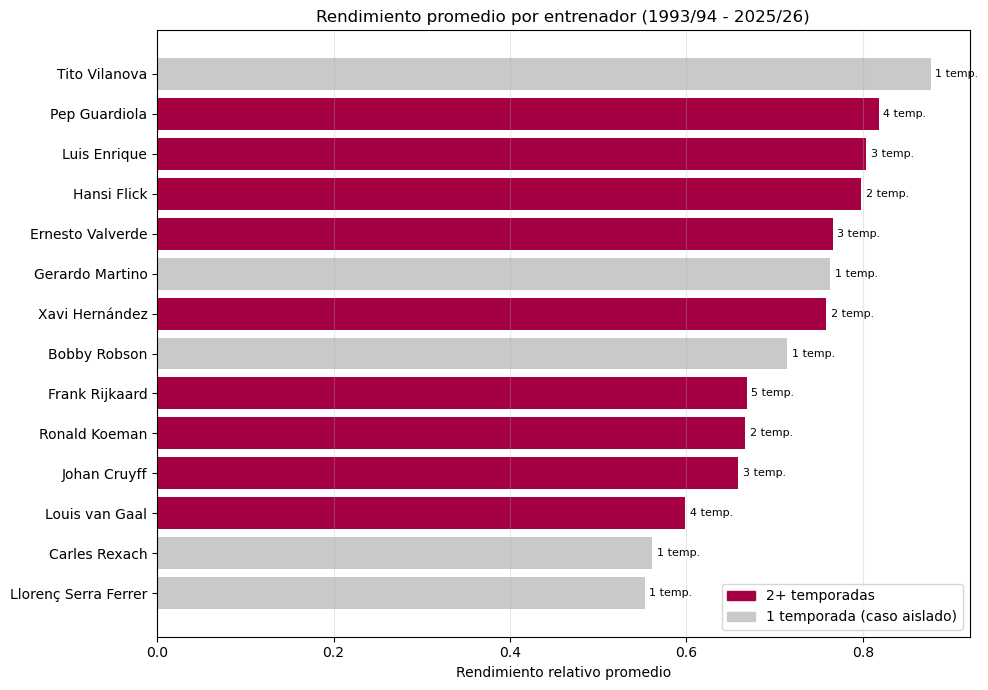

In [37]:
resumen_entrenadores['grupo'] = resumen_entrenadores['temporadas'].apply(
    lambda t: '2+ temporadas' if t >= 2 else '1 temporada (caso aislado)'
)

resumen_ordenado = resumen_entrenadores.sort_values('rendimiento_promedio', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colores_barras = resumen_ordenado['grupo'].map({
    '2+ temporadas': '#a50044',
    '1 temporada (caso aislado)': '#c9c9c9'
})

ax.barh(resumen_ordenado['entrenador_principal'], resumen_ordenado['rendimiento_promedio'], color=colores_barras)

for i, (rendimiento, temporadas) in enumerate(zip(resumen_ordenado['rendimiento_promedio'], resumen_ordenado['temporadas'])):
    ax.text(rendimiento + 0.005, i, f'{temporadas} temp.', va='center', fontsize=8)

ax.set_xlabel('Rendimiento relativo promedio')
ax.set_title('Rendimiento promedio por entrenador (1993/94 - 2025/26)')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
leyenda = [Patch(color='#a50044', label='2+ temporadas'), Patch(color='#c9c9c9', label='1 temporada (caso aislado)')]
ax.legend(handles=leyenda, loc='lower right')

plt.tight_layout()
fig.savefig('../reports/figures/rendimiento_por_entrenador.png', dpi=150, bbox_inches='tight')
plt.show()

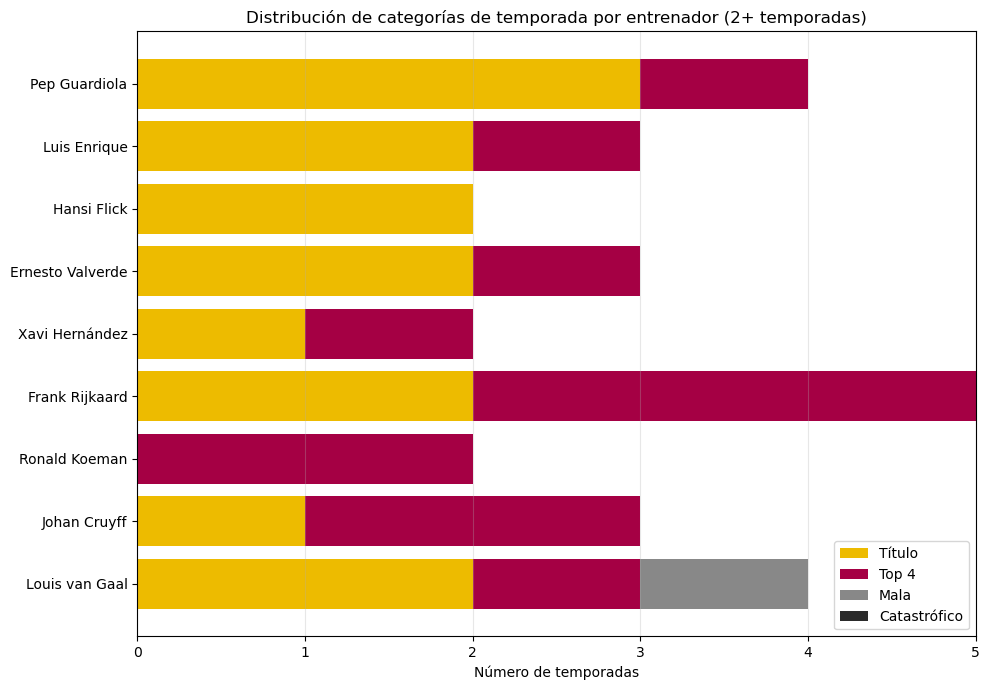

In [38]:
conteo_categorias = df_maestro[df_maestro['entrenador_principal'].isin(entrenadores_grandes)].groupby(
    ['entrenador_principal', 'categoria_temporada']
).size().unstack(fill_value=0)

orden_categorias = ['Título', 'Top 4', 'Mala', 'Catastrófico']
conteo_categorias = conteo_categorias.reindex(columns=orden_categorias, fill_value=0)

orden_entrenadores = resumen_confiable.sort_values('rendimiento_promedio')['entrenador_principal']
conteo_categorias = conteo_categorias.reindex(orden_entrenadores)

colores_categoria = {'Título': '#edbb00', 'Top 4': '#a50044', 'Mala': '#888888', 'Catastrófico': '#2b2b2b'}

fig, ax = plt.subplots(figsize=(10, 7))
izquierda = pd.Series(0, index=conteo_categorias.index)
for categoria in orden_categorias:
    ax.barh(conteo_categorias.index, conteo_categorias[categoria], left=izquierda,
             color=colores_categoria[categoria], label=categoria)
    izquierda += conteo_categorias[categoria]

ax.set_xlabel('Número de temporadas')
ax.set_title('Distribución de categorías de temporada por entrenador (2+ temporadas)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig('../reports/figures/categorias_por_entrenador.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis: rendimiento promedio por entrenador

Dentro del grupo de 2+ temporadas, **Pep Guardiola lidera con claridad** en rendimiento promedio (0.818) y también en el reparto de categorías: 3 de sus 4 temporadas fueron Título, la única excepción quedó en Top 4, nunca por debajo. **Hansi Flick tiene el mejor récord posible en las dos categorías**: sus 2 temporadas fueron Título, un 100% que ningún otro entrenador del grupo alcanza, aunque con la muestra más chica, a confirmar con más datos en el futuro.

**Luis Enrique y Ernesto Valverde muestran el mismo patrón** (2 Título, 1 Top 4 cada uno), consistentes con su rendimiento promedio similar (0.804 y 0.766). **Frank Rijkaard, con la muestra más grande (5 temporadas), tiene el mayor número de títulos en términos absolutos (2) pero también la mayor proporción de temporadas "solo" Top 4 (3 de 5)**, lo que explica por qué su promedio continuo (0.668) queda en la mitad baja pese a haber ganado 2 ligas: fue un entrenador de picos altos, pero con más temporadas de transición que picos.

**Louis van Gaal es el único entrenador de este grupo con una temporada en la categoría "Mala"** (posición 5-8), además de tener el rendimiento promedio más bajo (0.599), doble señal de una etapa irregular más que sólida.

**Ronald Koeman no ganó ningún título en sus 2 temporadas, pero ambas quedaron en Top 4, no en Mala**, un matiz que el rendimiento promedio bajo (0.667) no deja ver por sí solo: pese a la crisis institucional de esa etapa, el equipo siguió clasificando a Champions ambos años.

**Grupo de 1 sola temporada (no comparable):** destaca Tito Vilanova con el rendimiento más alto de todo el análisis (0.877), la temporada del récord de 100 puntos, un resultado extremo que ilustra por qué este grupo se trata aparte.|

In [42]:
df_plot = df_maestro.sort_values('anio_inicio').reset_index(drop=True)

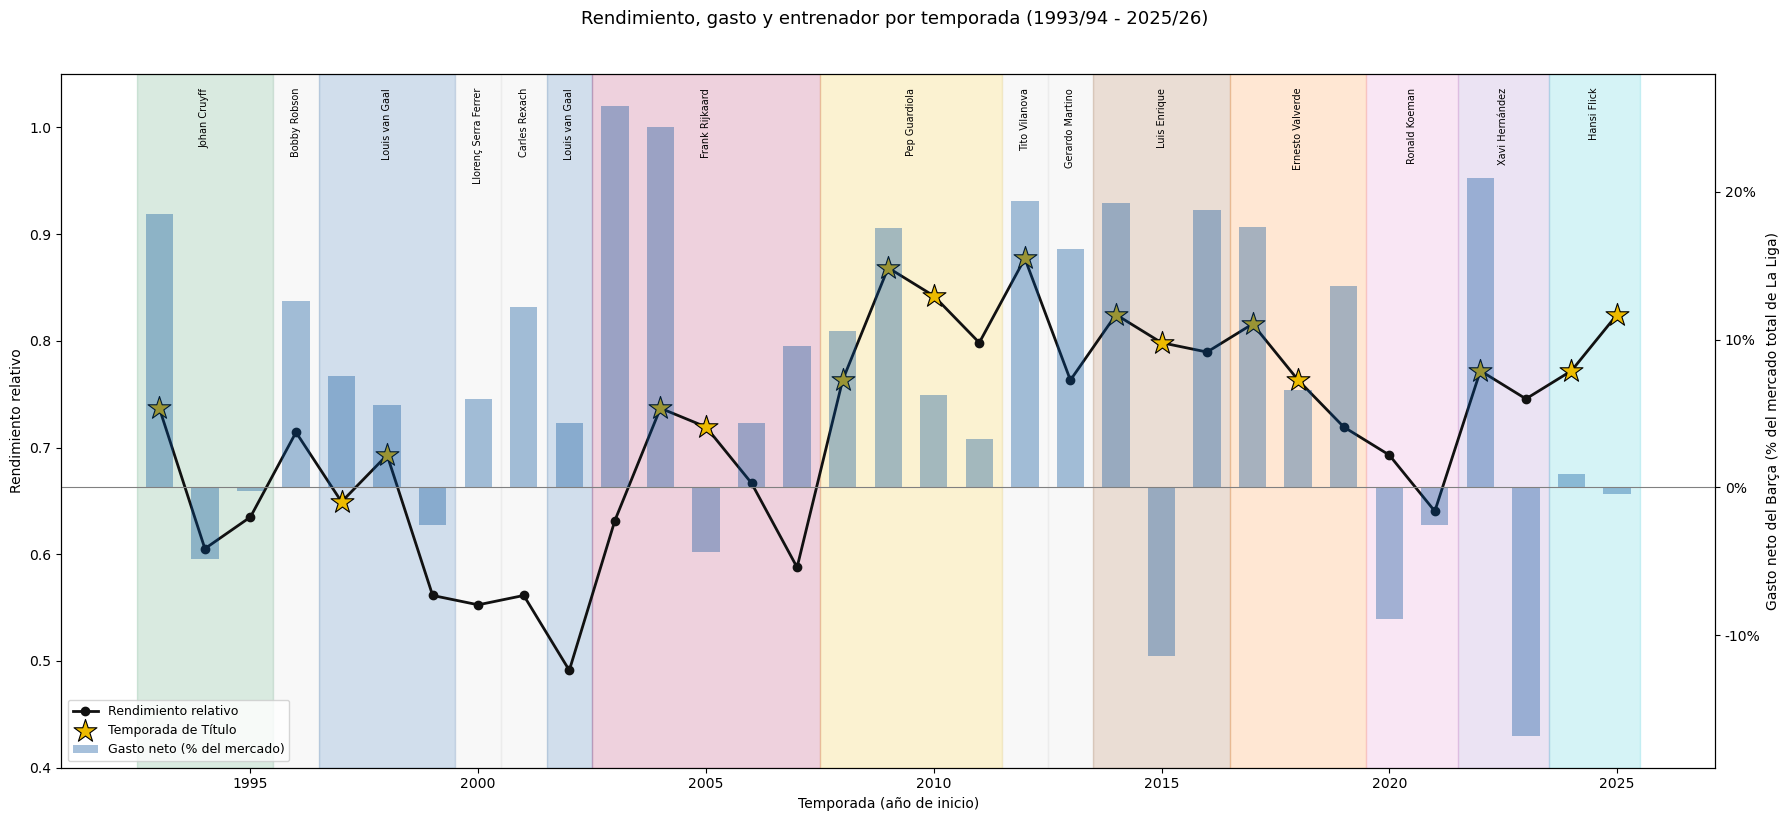

In [43]:
fig, ax1 = plt.subplots(figsize=(18, 8))

i = 0
while i < len(df_plot):
    entrenador = df_plot.loc[i, 'entrenador_principal']
    inicio = df_plot.loc[i, 'anio_inicio']
    j = i
    while j + 1 < len(df_plot) and df_plot.loc[j + 1, 'entrenador_principal'] == entrenador:
        j += 1
    fin = df_plot.loc[j, 'anio_inicio']
    color = mapa_color.get(entrenador, '#d9d9d9')
    ax1.axvspan(inicio - 0.5, fin + 0.5, color=color, alpha=0.18, zorder=0)
    ax1.text((inicio + fin) / 2, 0.98, entrenador, rotation=90, ha='center', va='top',
              fontsize=7, transform=ax1.get_xaxis_transform())
    i = j + 1

ax1.plot(df_plot['anio_inicio'], df_plot['rendimiento_relativo'], color='#111111',
          marker='o', linewidth=2, label='Rendimiento relativo', zorder=3)
ax1.set_ylabel('Rendimiento relativo')
ax1.set_xlabel('Temporada (año de inicio)')
ax1.set_ylim(0.4, 1.05)

titulos = df_plot[df_plot['categoria_temporada'] == 'Título']
ax1.scatter(titulos['anio_inicio'], titulos['rendimiento_relativo'], marker='*',
             s=300, color='#edbb00', edgecolor='black', linewidth=0.8, zorder=4, label='Temporada de Título')

ax2 = ax1.twinx()
ax2.bar(df_plot['anio_inicio'], df_plot['proporcion_mercado_barca'], alpha=0.35,
         color='#004d98', width=0.6, label='Gasto neto (% del mercado)', zorder=2)
ax2.set_ylabel('Gasto neto del Barça (% del mercado total de La Liga)')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax2.axhline(0, color='gray', linewidth=0.8)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9)

fig.suptitle('Rendimiento, gasto y entrenador por temporada (1993/94 - 2025/26)', y=1.02, fontsize=13)
plt.tight_layout()
fig.savefig('../reports/figures/panorama_completo.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualización integradora: rendimiento, gasto y entrenador en el tiempo

Se construyó un gráfico de doble eje que combina las tres variables centrales del proyecto en una sola vista: el rendimiento relativo como línea, el gasto neto (% del mercado) como barras, y el entrenador como fondo coloreado por tramos temporales.

**Hallazgos que emergen solo al verlas juntas:**
- El primer año de cada nuevo entrenador suele coincidir con una barra de gasto alta (Cruyff, Rijkaard, Guardiola, Vilanova, Xavi), un patrón de inversión de renovación de ciclo.
- La temporada 2003/04 (inicio de Rijkaard) tiene el mayor gasto relativo de las 33 temporadas, y el rendimiento efectivamente responde con fuerza en los años siguientes, aunque hacia el final del ciclo (2006/07-2007/08) el gasto se sostiene mientras el rendimiento cae, mostrando visualmente el agotamiento de una etapa.
- La segunda etapa de Van Gaal (2002/03) combina la única venta neta grande del periodo con la caída de rendimiento más profunda del gráfico completo.
- La temporada de la sanción FIFA (2015/16, bajo Luis Enrique) muestra la única barra fuertemente negativa dentro de un ciclo ganador, sin que el rendimiento se vea afectado, un contraejemplo visual directo a la narrativa de "hace falta gastar para rendir".

## Extensión: ataque vs defensa

Hasta ahora se usó diferencia de gol (ataque menos defensa combinados) como parte del rendimiento, sin evaluar si el ataque o la defensa pesan más por separado. Se calcula la correlación de cada uno con `rendimiento_relativo` de forma independiente, para no asumir que "más goles a favor" es automáticamente sinónimo de mejor temporada.

In [ ]:
corr_favor, p_favor = pearsonr(df_maestro['goles_favor'], df_maestro['rendimiento_relativo'])
corr_contra, p_contra = pearsonr(df_maestro['goles_contra'], df_maestro['rendimiento_relativo'])

print(f'Goles a favor vs rendimiento: r={corr_favor:.3f}, p={p_favor:.3f}')
print(f'Goles en contra vs rendimiento: r={corr_contra:.3f}, p={p_contra:.3f}')

Goles a favor vs rendimiento: r=0.787, p=0.000
Goles en contra vs rendimiento: r=-0.660, p=0.000


**Interpretación:** ambas correlaciones son altamente significativas, pero de distinta magnitud. El ataque (r=0.787) pesa más que la defensa (r=-0.660), sugiriendo que meter goles explica más el rendimiento del Barça que evitar recibirlos, coherente con la identidad ofensiva del club en la mayoría de las eras analizadas.

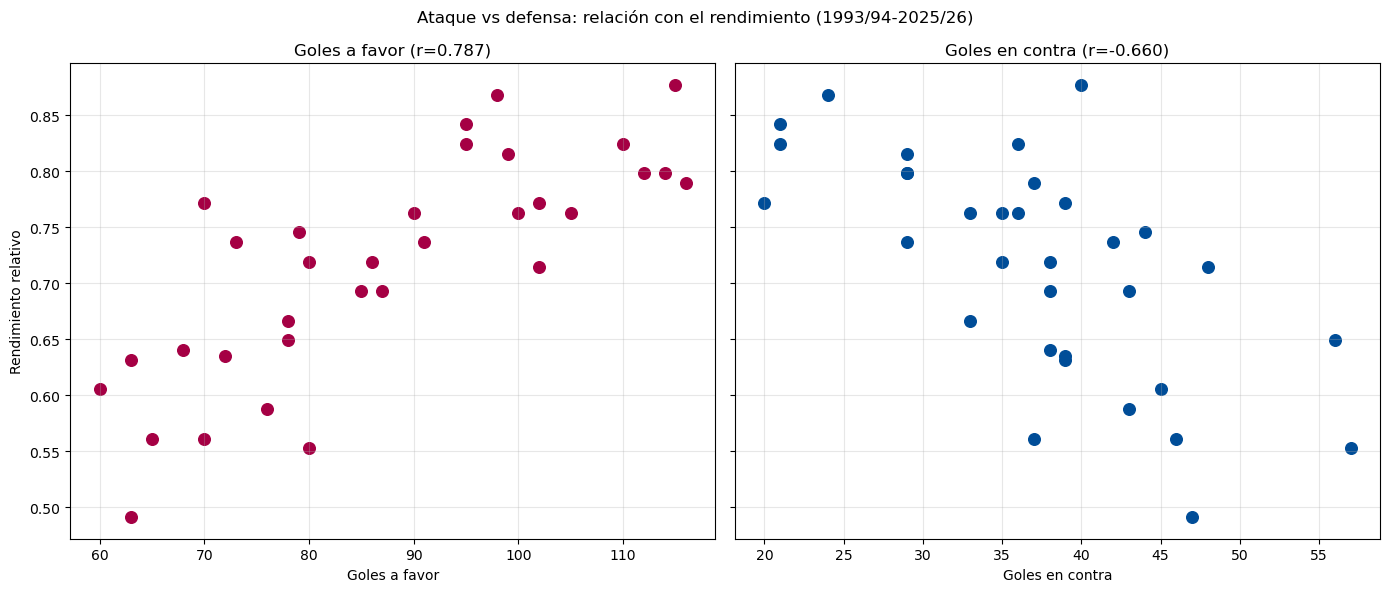

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].scatter(df_maestro['goles_favor'], df_maestro['rendimiento_relativo'], color='#a50044', s=70)
axes[0].set_xlabel('Goles a favor')
axes[0].set_ylabel('Rendimiento relativo')
axes[0].set_title(f'Goles a favor (r={corr_favor:.3f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_maestro['goles_contra'], df_maestro['rendimiento_relativo'], color='#004d98', s=70)
axes[1].set_xlabel('Goles en contra')
axes[1].set_title(f'Goles en contra (r={corr_contra:.3f})')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Ataque vs defensa: relación con el rendimiento (1993/94-2025/26)')
plt.tight_layout()
fig.savefig('../reports/figures/ataque_vs_defensa.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
for entrenador in entrenadores_grandes:
    sub = df_maestro[df_maestro['entrenador_principal'] == entrenador]
    if len(sub) >= 3:
        c_favor, _ = pearsonr(sub['goles_favor'], sub['rendimiento_relativo'])
        c_contra, _ = pearsonr(sub['goles_contra'], sub['rendimiento_relativo'])
        print(f'{entrenador}: goles_favor r={c_favor:.2f} | goles_contra r={c_contra:.2f}')

Frank Rijkaard: goles_favor r=0.29 | goles_contra r=-0.90
Louis van Gaal: goles_favor r=0.99 | goles_contra r=0.08
Pep Guardiola: goles_favor r=-0.65 | goles_contra r=-0.90
Johan Cruyff: goles_favor r=0.98 | goles_contra r=-0.21
Luis Enrique: goles_favor r=-0.89 | goles_contra r=-0.96
Ernesto Valverde: goles_favor r=0.99 | goles_contra r=-0.97


### Lectura de los gráficos y del desglose por entrenador

Los dos scatter muestran visualmente lo que ya decía el coeficiente: los puntos de goles a favor forman una tendencia ascendente más definida que los de goles en contra, aunque ambos muestran relación clara con el rendimiento.

**Precaución sobre el desglose por entrenador:** con solo 3 a 5 temporadas por entrenador, los coeficientes individuales son altamente inestables, no una medición confiable. El caso más claro es Guardiola, cuyo `goles_favor` sale negativo (r=-0.65) dentro de su propia etapa, contradiciendo el patrón general del dataset completo (r=0.787): con una muestra tan chica, un solo año atípico puede voltear el signo entero. Estos números por entrenador se muestran como referencia exploratoria, no como evidencia estadística válida, y no deben usarse para afirmar que un entrenador específico dependía más del ataque o de la defensa.

**Único patrón que vale la pena señalar con cautela:** tanto Rijkaard como Guardiola, las dos eras de mayor éxito sostenido del club, muestran su coeficiente de `goles_contra` más fuerte que el de `goles_favor` (ambos con r≈-0.90 en defensa), lo opuesto al patrón general del dataset. Es sugerente, no concluyente, pero plantea una pregunta interesante para retomar si en el futuro se amplía la muestra: ¿las eras más dominantes se sostienen más en la solidez defensiva que en el promedio general del club?

**Conclusión de la sección:** a nivel de todo el dataset (33 temporadas), el ataque explica más varianza del rendimiento que la defensa (r=0.787 vs r=-0.660, ambos altamente significativos). El desglose por entrenador no cambia esta conclusión general, solo revela que la relación puede comportarse distinto dentro de eras específicas, algo que requeriría más datos por entrenador para confirmar con rigor.

## Extensión: rendimiento local vs visitante

Se separa el rendimiento del Barça por condición (local/visitante) en cada temporada, usando `partidos_barca_completo.csv`, para evaluar si el club depende más de jugar en casa, y si esa dependencia cambia por entrenador o por era.

In [46]:
partidos = pd.read_csv('../data/processed/partidos_barca_completo.csv', dtype={'temporada': str})

partidos['condicion'] = partidos['HomeTeam'].apply(lambda x: 'local' if x == 'Barcelona' else 'visitante')
partidos['puntos_por_victoria'] = partidos['temporada'].apply(lambda t: 2 if t in ['9394', '9495'] else 3)

partidos['resultado'] = 'empate'
partidos.loc[partidos['goles_barca'] > partidos['goles_rival'], 'resultado'] = 'victoria'
partidos.loc[partidos['goles_barca'] < partidos['goles_rival'], 'resultado'] = 'derrota'

partidos['puntos'] = partidos.apply(
    lambda row: row['puntos_por_victoria'] if row['resultado'] == 'victoria' else (1 if row['resultado'] == 'empate' else 0),
    axis=1
)

In [47]:
rendimiento_condicion = partidos.groupby(['temporada', 'condicion']).agg(
    partidos_jugados=('resultado', 'count'),
    puntos=('puntos', 'sum'),
    goles_favor=('goles_barca', 'sum'),
    goles_contra=('goles_rival', 'sum')
).reset_index()

rendimiento_condicion['diferencia_gol'] = rendimiento_condicion['goles_favor'] - rendimiento_condicion['goles_contra']
rendimiento_condicion['puntos_por_partido'] = rendimiento_condicion['puntos'] / rendimiento_condicion['partidos_jugados']

rendimiento_condicion.head(10)

,temporada,condicion,partidos_jugados,puntos,goles_favor,goles_contra,diferencia_gol,puntos_por_partido
0,0001,local,19,40,51,24,27,2.105263
1,0001,visitante,19,23,29,33,-4,1.210526
2,0102,local,19,41,44,17,27,2.157895
3,0102,visitante,19,23,21,20,1,1.210526
4,0203,local,19,35,43,24,19,1.842105
5,0203,visitante,19,21,20,23,-3,1.105263
6,0304,local,19,36,33,14,19,1.894737
7,0304,visitante,19,36,30,25,5,1.894737
8,0405,local,19,46,40,12,28,2.421053
9,0405,visitante,19,38,33,17,16,2.000000


In [48]:
brecha = rendimiento_condicion.pivot(index='temporada', columns='condicion', values='puntos_por_partido')
brecha['brecha_local_visitante'] = brecha['local'] - brecha['visitante']
brecha = brecha.merge(df_maestro[['temporada', 'anio_inicio', 'entrenador_principal']], on='temporada')
brecha = brecha.sort_values('anio_inicio').reset_index(drop=True)

brecha.head(10)

,temporada,local,visitante,brecha_local_visitante,anio_inicio,entrenador_principal
0,9394,1.736842,1.210526,0.526316,1993,Johan Cruyff
1,9495,1.526316,0.894737,0.631579,1994,Johan Cruyff
2,9596,2.380952,1.428571,0.952381,1995,Johan Cruyff
3,9697,2.571429,1.714286,0.857143,1996,Bobby Robson
4,9798,2.263158,1.631579,0.631579,1997,Louis van Gaal
5,9899,2.210526,1.947368,0.263158,1998,Louis van Gaal
6,9900,2.157895,1.210526,0.947368,1999,Louis van Gaal
7,0001,2.105263,1.210526,0.894737,2000,Llorenç Serra Ferrer
8,0102,2.157895,1.210526,0.947368,2001,Carles Rexach
9,0203,1.842105,1.105263,0.736842,2002,Louis van Gaal


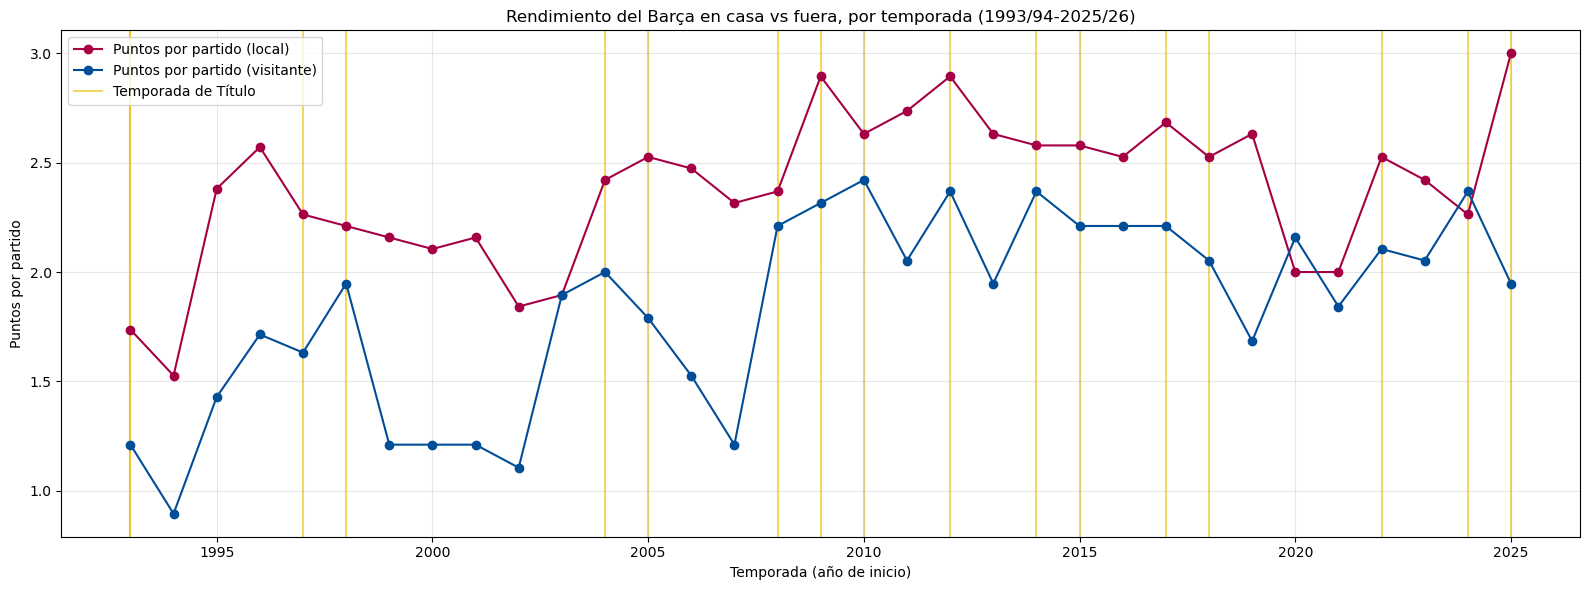

In [53]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(brecha['anio_inicio'], brecha['local'], marker='o', color='#a50044', label='Puntos por partido (local)')
ax.plot(brecha['anio_inicio'], brecha['visitante'], marker='o', color='#004d98', label='Puntos por partido (visitante)')

anios_titulo = df_maestro[df_maestro['categoria_temporada'] == 'Título']['anio_inicio']
for anio in anios_titulo:
    ax.axvline(anio, color='#edbb00', linewidth=1.5, alpha=0.6, zorder=1)

ax.axvline(anios_titulo.iloc[0], color='#edbb00', linewidth=1.5, alpha=0.6, zorder=1, label='Temporada de Título')

ax.set_xlabel('Temporada (año de inicio)')
ax.set_ylabel('Puntos por partido')
ax.set_title('Rendimiento del Barça en casa vs fuera, por temporada (1993/94-2025/26)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('../reports/figures/local_vs_visitante.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
top_visitante = brecha.sort_values('visitante', ascending=False)[['temporada', 'entrenador_principal', 'local', 'visitante', 'brecha_local_visitante']].head(5)
top_visitante

,temporada,entrenador_principal,local,visitante,brecha_local_visitante
17,1011,Pep Guardiola,2.631579,2.421053,0.210526
19,1213,Tito Vilanova,2.894737,2.368421,0.526316
31,2425,Hansi Flick,2.263158,2.368421,-0.105263
21,1415,Luis Enrique,2.578947,2.368421,0.210526
16,0910,Pep Guardiola,2.894737,2.315789,0.578947


In [54]:
def contexto_atipico(temporada):
    if temporada == '2021':
        return 'Pandemia (temporada completa sin público)'
    elif temporada in ['2324', '2425']:
        return 'Local en Montjuïc (temporada completa fuera del Camp Nou)'
    else:
        return None

brecha['contexto_atipico'] = brecha['temporada'].apply(contexto_atipico)
brecha[brecha['contexto_atipico'].notna()]

,temporada,local,visitante,brecha_local_visitante,anio_inicio,entrenador_principal,contexto_atipico
27,2021,2.000000,2.157895,-0.157895,2020,Ronald Koeman,Pandemia (temporada completa sin público)
30,2324,2.421053,2.052632,0.368421,2023,Xavi Hernández,Local en Montjuïc (temporada completa fuera de...
31,2425,2.263158,2.368421,-0.105263,2024,Hansi Flick,Local en Montjuïc (temporada completa fuera de...


### Rendimiento local vs visitante: hallazgos

El Barça rinde mejor en casa que fuera en la gran mayoría de las 33 temporadas, pero la brecha se ha achicado con el tiempo: los años 90 y 2000 muestran diferencias más marcadas que la última década, donde ambas líneas se mueven más cerca entre sí.

**Nota metodológica: tres temporadas tienen un factor externo que altera el significado habitual de "local", cada una por un motivo distinto, y solo se marcan las que afectaron más de la mitad del calendario de esa temporada:**

- **2020/21**: la temporada completa se jugó a puerta cerrada por la pandemia, sin el efecto de público en ningún estadio de la liga, ni a favor del Barça ni de sus rivales. Esto reduce la brecha local-visitante en general (menos ventaja de jugar en casa para todos los equipos), no la invierte.
- **2023/24 y 2024/25**: el Barça jugó como local en el Estadio Olímpico de Montjuïc durante ambas temporadas completas, por la remodelación del Camp Nou. A diferencia de la pandemia (que afecta a toda la liga por igual), esto es un factor específico del Barça: su "local" no tuvo la ventaja histórica ni el aforo del Camp Nou, lo que puede explicar por qué 2024/25 es la única temporada del rango completo con brecha negativa (mejor rendimiento de "visitante" que de "local").

**Nota:** 2019/20 también tuvo partidos sin público (jornadas 28-38 tras la reanudación pospandemia), pero al cubrir menos de la mitad del calendario, no se marca bajo el mismo criterio.

**Con estas salvedades**, Tito Vilanova (2012/13) queda como el caso más sólido de fortaleza real de visitante dentro de un contexto normal: segundo mejor promedio de visitante de todo el rango, a la vez que uno de los mejores en casa (Camp Nou real, con público), mostrando dominio efectivo en ambos lados sin ningún factor externo de por medio.

**Sobre el título y la condición de local:** las temporadas de Título se distribuyen a lo largo de todo el gráfico, sin agruparse en las de mayor brecha local-visitante, sugiriendo que ganar la liga no depende de un perfil específico de dominio casero, sino del nivel general del equipo en ambas condiciones.

### Cierre del notebook: conclusiones de la Fase 1

A lo largo de este notebook se definieron las métricas de rendimiento (`rendimiento_relativo`, `categoria_temporada`) y de gasto ajustado por mercado (`proporcion_mercado_barca`), y se analizó su relación entre sí, con el entrenador a cargo, con el balance ataque/defensa, y con la condición de local/visitante, a través de nueve visualizaciones: rendimiento histórico, proporción de mercado vs rendimiento, boxplot de gasto por categoría, rendimiento por entrenador, categorías por entrenador, la vista integradora de gasto/rendimiento/entrenador en el tiempo, ataque vs defensa, y rendimiento local vs visitante.

**Conclusión general:**

- **El gasto neto en fichajes, incluso ajustado por el tamaño del mercado, no muestra una relación estadísticamente significativa con el rendimiento** del Barça en el rango 1993/94-2025/26 (r=0.227, p=0.204). El entrenador, en cambio, se asocia con una diferencia más marcada y consistente en el rendimiento promedio, y el gráfico integrador sugiere que el gasto tiende a concentrarse al inicio de cada ciclo de entrenador, más como una inversión de renovación que como un predictor directo de éxito esa temporada.
- **El ataque explica más varianza del rendimiento que la defensa**, ambos con correlaciones altamente significativas (goles a favor r=0.787, goles en contra r=-0.660, p<0.001 en ambos casos), coherente con la identidad ofensiva del club a lo largo de la mayoría de las eras analizadas.
- **El Barça depende de jugar en casa en la mayoría de las temporadas**, aunque esa brecha se ha achicado con el tiempo. Tres temporadas (2020/21, 2023/24, 2024/25) tienen un factor externo que altera el significado habitual de "local" (pandemia sin público, y remodelación del Camp Nou con sede en Montjuïc, respectivamente), documentado explícitamente para no confundir esos casos con una fortaleza o debilidad real de visitante. Ninguna de las temporadas de Título se concentra en los extremos de mayor o menor dependencia del local, sugiriendo que ganar la liga no depende de un perfil específico de dominio casero.

Esto es consistente con la hipótesis inicial del proyecto sobre el peso del entrenador por encima del gasto, pero se trata de evidencia descriptiva robusta, no de una prueba causal.

**Con esto se cierra la Fase 1 del proyecto.** El siguiente notebook (`03_analisis_cantera.ipynb`) aborda la Fase 2: uso de canteranos por temporada.